In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [5]:
df.shape


(614, 13)

# 1. Handling Missing Values


In [6]:
# Categorical Mode Imputation
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
# Numerical Imputation
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# 2. Converting Dependents

In [8]:
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# 3. Encoding Categorical Variables

In [9]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Married'] = df['Married'].map({'Yes':1, 'No':0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})

df['Property_Area'] = df['Property_Area'].map({'Urban':2, 'Semiurban':1, 'Rural':0})

df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

# 4. Creating Total Income Feature (Advanced)

In [10]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 5. LoanAmount Log Transform

In [11]:
df['LoanAmount_log'] = np.log(df['LoanAmount'])

# 6. Final Check

In [12]:
print(df.isnull().sum())
df.head()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Total_Income         0
LoanAmount_log       0
dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,LoanAmount_log
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,4.852030
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,4.852030
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,4.189655
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,4.787492
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,4.948760


#EDA

# 1. Import Libraries

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 2. Univariate Analysis

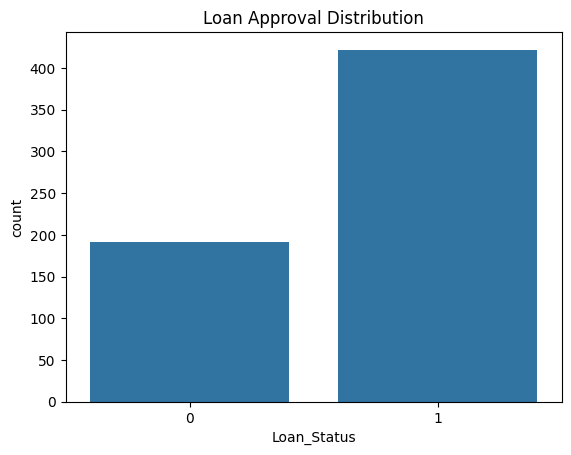

In [14]:
#Loan Status Distribution
sns.countplot(data=df, x='Loan_Status')
plt.title('Loan Approval Distribution')
plt.show()


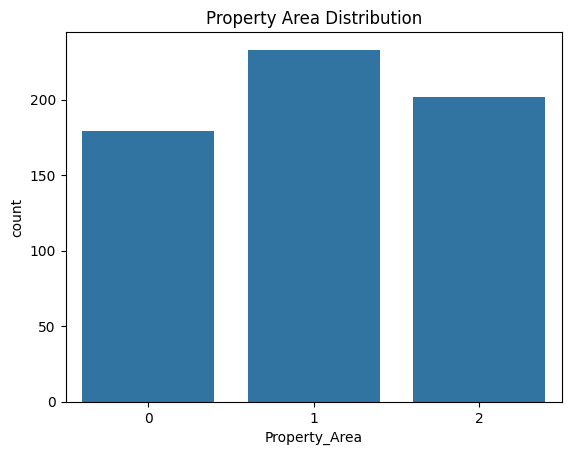

In [15]:
#Property Area
sns.countplot(data=df, x='Property_Area')
plt.title('Property Area Distribution')
plt.show()


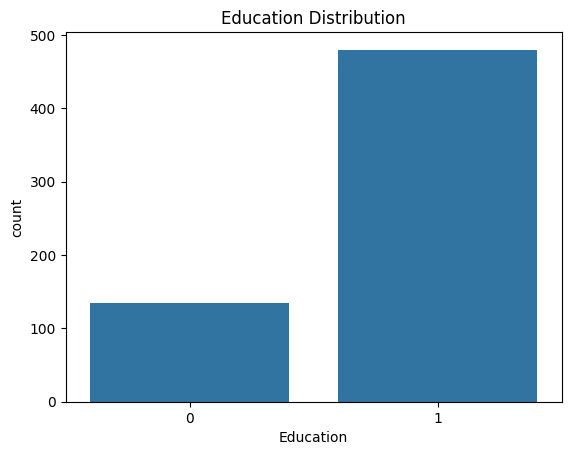

In [16]:
#Education
sns.countplot(data=df, x='Education')
plt.title('Education Distribution')
plt.show()


# 3. Bivariate Analysis

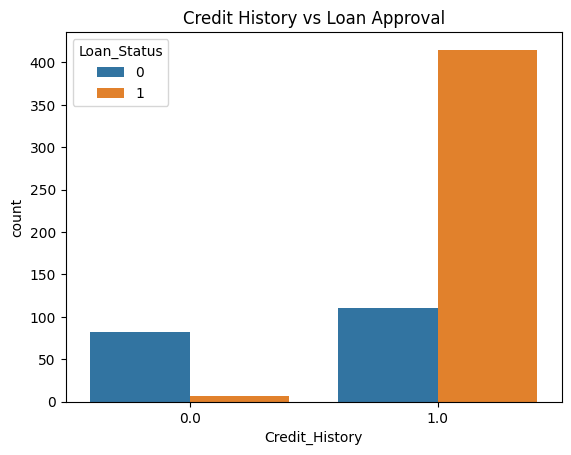

In [17]:
#Loan Status vs Credit History
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Approval')
plt.show()

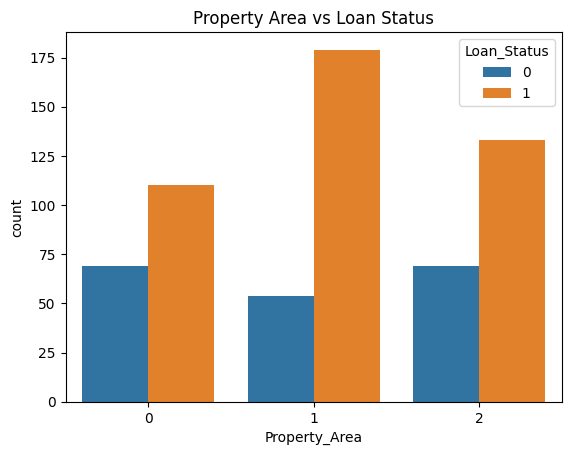

In [18]:
#Loan Status vs Property Area
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title('Property Area vs Loan Status')
plt.show()


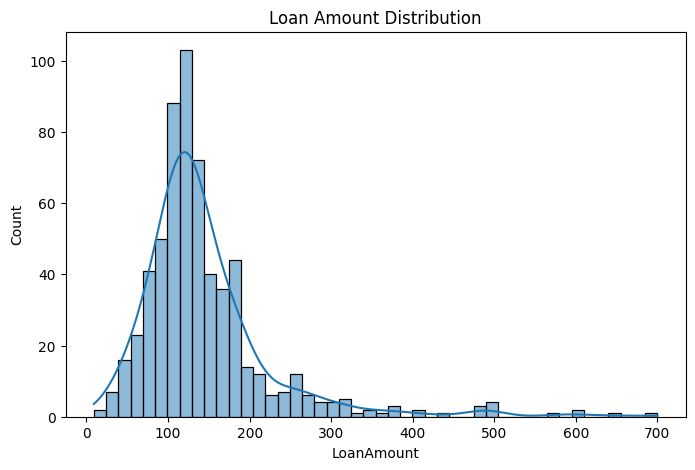

In [19]:
#Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Loan Amount Distribution')
plt.show()


# 4. Income vs Loan Amount

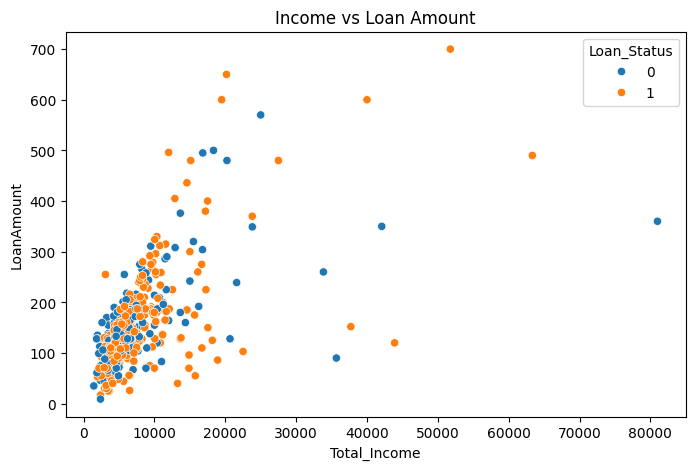

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Total_Income'], y=df['LoanAmount'], hue=df['Loan_Status'])
plt.title('Income vs Loan Amount')
plt.show()

# 5. Correlation Heatmap

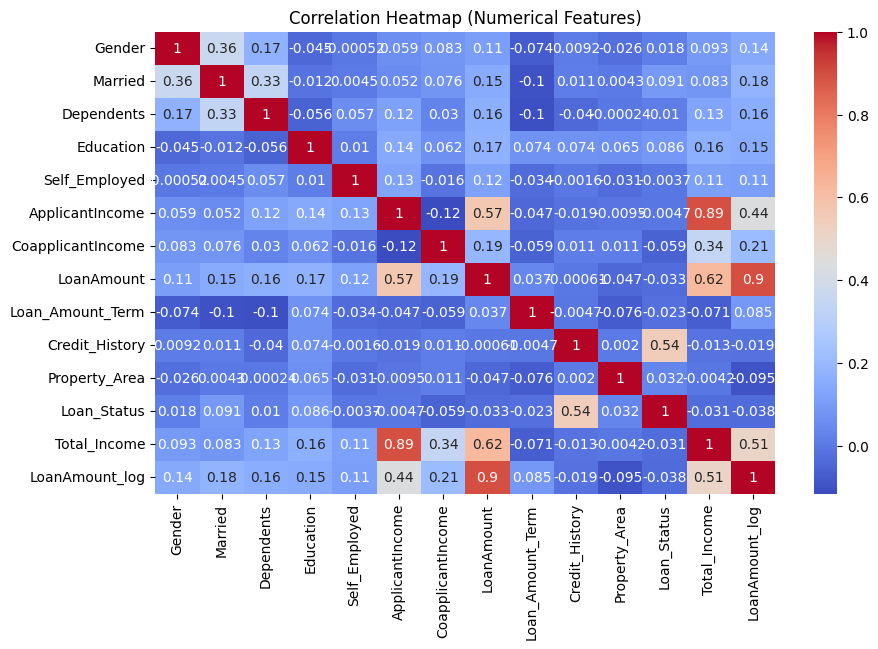

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


In [22]:
df.to_csv("clean_loan_data.csv", index=False)
